In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv("laptops_analysis.csv")

In [3]:
df.head() # showing the first 5 rows of dataset

,Product Name,Processor,RAM,SSD,Display,Price,Discount,Rating
0,HP Chromebook MediaTek Kompanio 540 - (4 GB/12...,MediaTek MediaTek Kompanio 540 Processor,4 GB LPDDR5 RAM,128 GB SSD,35.56 cm (14 inch) Display,"₹36,990",37% off,4.5
1,HP Chromebook (TouchScreen) MediaTek Kompanio ...,MediaTek MediaTek Kompanio 540 Processor,4 GB LPDDR5 RAM,128 GB SSD,35.56 cm (14 inch) Touchscreen Display,"₹39,990",40% off,3.8
2,Acer Aspire 15 Lite(i5 14th Gen) Intel Core 5 ...,Intel Core 5 Processor,16 GB LPDDR5 RAM,512 GB SSD,39.62 cm (15.6 inch) Display,"₹59,990",24% off,4.4
3,Ultimus Apex Pro Intel Pentium Quad Core N4200...,Intel Pentium Quad Core Processor,4 GB DDR3 RAM,128 GB SSD,35.81 cm (14.1 inch) Display,"₹19,990",28% off,3.3
4,WarnerCann N95 Notebook Intel Core N 12th Gen ...,Intel Core N Processor (12th Gen),12 GB DDR4 RAM,256 GB SSD,38.86 cm (15.3 Inch) Display,"₹22,318",41% off,NaN


In [4]:
df.tail() # Showing the last 5 rows of the dataset

,Product Name,Processor,RAM,SSD,Display,Price,Discount,Rating
979,Lenovo Legion 5 2025 Intel Core i7 13650HX - (...,Intel Core i7 Processor,16 GB DDR5 RAM,1 TB SSD,38.86 cm (15.3 inch) Display,"₹1,85,490",11% off,4.0
980,Samsung Galaxy Book4 360 Evo (i7 14th Gen) Int...,Intel Core 7 Processor,16 GB LPDDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Touchscreen Display,"₹1,09,899",22% off,4.2
981,Lenovo LOQ AMD Ryzen 5 Quad Core 7235HS - (24 ...,AMD Ryzen 5 Quad Core Processor,24 GB DDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,"₹77,990",22% off,4.4
982,Acer 1305U Intel Core i3 13th Gen 1305U - (8 G...,Intel Core i3 Processor (13th Gen),8 GB DDR4 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,"₹68,990",13% off,NaN
983,Samsung Galaxy Book6 Intel Core Ultra 5 Series...,Intel Core Ultra 5 Processor (Series 3),16 GB LPDDR5X RAM,512 GB SSD,35.56 cm (14 inch) Display,"₹1,12,990",20% off,NaN


In [5]:
df.info() # describing the overall summary of data such as (total rows and columns,column_names,data types, nullvalues,memory usage)

<class 'pandas.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  984 non-null    str    
 1   Processor     984 non-null    str    
 2   RAM           984 non-null    str    
 3   SSD           962 non-null    str    
 4   Display       984 non-null    str    
 5   Price         984 non-null    str    
 6   Discount      831 non-null    str    
 7   Rating        824 non-null    float64
dtypes: float64(1), str(7)
memory usage: 61.6 KB


In [6]:
df.shape

(984, 8)

In [7]:
df.describe() # here we have rating column only shows numerical and all the reamaining columns shows as string

,Rating
count,824.000000
mean,4.190291
std,0.373650
min,2.000000
25%,4.000000
50%,4.200000
75%,4.400000
max,5.000000


### 2. Data Cleaning
**Handle missing values**

In [8]:
df.isnull().sum() # Check any missing values are there in the data

Product Name      0
Processor         0
RAM               0
SSD              22
Display           0
Price             0
Discount        153
Rating          160
dtype: int64

In [9]:
print(df.columns)

Index(['Product Name', 'Processor', 'RAM', 'SSD', 'Display', 'Price',
       'Discount', 'Rating'],
      dtype='str')


In [10]:
df["SSD"] = df["SSD"].fillna(df["SSD"].mode()[0])

In [11]:
df["Discount"] = df["Discount"].fillna(df["Discount"].mode()[0])

In [12]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [13]:
df.isnull().sum()

Product Name    0
Processor       0
RAM             0
SSD             0
Display         0
Price           0
Discount        0
Rating          0
dtype: int64

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  984 non-null    str    
 1   Processor     984 non-null    str    
 2   RAM           984 non-null    str    
 3   SSD           984 non-null    str    
 4   Display       984 non-null    str    
 5   Price         984 non-null    str    
 6   Discount      984 non-null    str    
 7   Rating        984 non-null    float64
dtypes: float64(1), str(7)
memory usage: 61.6 KB


### Remove duplicates

In [15]:
df.duplicated().sum()

np.int64(258)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 726 entries, 0 to 983
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  726 non-null    str    
 1   Processor     726 non-null    str    
 2   RAM           726 non-null    str    
 3   SSD           726 non-null    str    
 4   Display       726 non-null    str    
 5   Price         726 non-null    str    
 6   Discount      726 non-null    str    
 7   Rating        726 non-null    float64
dtypes: float64(1), str(7)
memory usage: 51.0 KB


### Use Regular Expressions for at least 5 data-cleaning or extraction tasks

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 726 entries, 0 to 983
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  726 non-null    str    
 1   Processor     726 non-null    str    
 2   RAM           726 non-null    str    
 3   SSD           726 non-null    str    
 4   Display       726 non-null    str    
 5   Price         726 non-null    str    
 6   Discount      726 non-null    str    
 7   Rating        726 non-null    float64
dtypes: float64(1), str(7)
memory usage: 51.0 KB


In [20]:
# remove rupee symbol and comma 
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace(r"[₹,]", "", regex=True)
)

In [21]:
df["Price"].head()

0    36990
1    39990
2    59990
3    19990
4    22318
Name: Price, dtype: str

In [22]:
# shows only cm value
df["Display"] = df["Display"].str.extract(r'(\d+\.\d+)\s*cm')

In [23]:
df["Display"].head()

0    35.56
1    35.56
2    39.62
3    35.81
4    38.86
Name: Display, dtype: str

In [24]:
# Extract RAM Size (GB)

df["RAM"] = (
    df["RAM"]
    .astype(str)
    .str.extract(r'(\d+)\s*GB', expand=False)
)

In [25]:
df["RAM"].head()

0     4
1     4
2    16
3     4
4    12
Name: RAM, dtype: str

In [26]:
# Extract SSD Capacity

df["SSD"] = df["SSD"].str.extract(r'(\d+\s*(?:GB|TB))')

In [27]:
df["SSD"].head()

0    128 GB
1    128 GB
2    512 GB
3    128 GB
4    256 GB
Name: SSD, dtype: str

In [28]:
# Extract Processor Brand

df["Processor"] = df["Processor"].str.extract(r'(Kompanio|Intel|AMD|Apple|Snapdragon)')

In [29]:
df["Processor"].head()

0    Kompanio
1    Kompanio
2       Intel
3       Intel
4       Intel
Name: Processor, dtype: str

In [30]:
df["Discount"] = (
    df["Discount"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

In [31]:
df["Discount"].head()

0    37
1    40
2    24
3    28
4    41
Name: Discount, dtype: str

In [32]:
df["Processor"] = df["Processor"].fillna(df["Processor"].mode()[0])

In [33]:
df["Display"] = df["Display"].fillna(df["Display"].mode()[0])

In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 726 entries, 0 to 983
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  726 non-null    str    
 1   Processor     726 non-null    str    
 2   RAM           726 non-null    str    
 3   SSD           726 non-null    str    
 4   Display       726 non-null    str    
 5   Price         726 non-null    str    
 6   Discount      726 non-null    str    
 7   Rating        726 non-null    float64
dtypes: float64(1), str(7)
memory usage: 51.0 KB


### Convert data into appropriate data types

In [35]:
# converting price,Discount columns string to integer

df["Price"] = pd.to_numeric(df["Price"], errors="coerce").astype("Int64")

In [36]:
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce").astype("Int64")

In [37]:
print(df[["Price", "Discount"]].dtypes)

Price       Int64
Discount    Int64
dtype: object


In [56]:
df["Price"] = df["Price"].fillna(df["Price"].median())

In [58]:
df["Price_After_Discount"] = df["Price_After_Discount"].fillna(df["Price_After_Discount"].median())

In [59]:
df.info()

<class 'pandas.DataFrame'>
Index: 726 entries, 0 to 983
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product Name          726 non-null    str    
 1   Processor             726 non-null    str    
 2   RAM                   726 non-null    str    
 3   SSD                   726 non-null    str    
 4   Display               726 non-null    str    
 5   Price                 726 non-null    Int64  
 6   Discount              726 non-null    Int64  
 7   Rating                726 non-null    float64
 8   Price_After_Discount  726 non-null    Float64
 9   Price_Category        726 non-null    str    
 10  Screen_Type           726 non-null    str    
 11  Rating_Category       726 non-null    str    
 12  Brand                 726 non-null    object 
dtypes: Float64(1), Int64(2), float64(1), object(1), str(8)
memory usage: 81.5+ KB


In [62]:
df.to_csv("laptops_analysis.csv", index=False)
print("CSV file saved successfully!")

CSV file saved successfully!


### 3. Feature Engineering
**Create at least 3 new columns from the scraped data.**

In [63]:
df1 = pd.read_csv("laptops_analysis.csv")

In [64]:
# Create a Final Price column

df1["Price_After_Discount"] = df["Price"] - (df["Price"] * df["Discount"] / 100)
df1["Price_After_Discount"]

0       23303.7
1       23994.0
2       45592.4
3       14392.8
4      13167.62
         ...   
721        <NA>
722        <NA>
723     61023.0
724     47999.4
725     80991.0
Name: Price_After_Discount, Length: 726, dtype: Float64

In [66]:
# Create a Price Category column

df1["Price_Category"] = "Budget"
df1.loc[df1["Price"] >= 50000, "Price_Category"] = "Premium"
df1["Price_Category"]

0       Budget
1       Budget
2      Premium
3       Budget
4       Budget
        ...   
721    Premium
722    Premium
723    Premium
724    Premium
725    Premium
Name: Price_Category, Length: 726, dtype: str

In [74]:
# Create a Screen Type column

df1["Screen_Type"] = "Standard"
df1.loc[df1["Display"] == 15.6, "Screen_Type"] = "Large"
df1["Screen_Type"]

0      Standard
1      Standard
2      Standard
3      Standard
4      Standard
         ...   
721    Standard
722    Standard
723    Standard
724    Standard
725    Standard
Name: Screen_Type, Length: 726, dtype: str

In [70]:
# # Create a Rating_Category 

df1["Rating_Category"] = "Average"
df1.loc[df1["Rating"] >= 4.2, "Rating_Category"] = "Excellent"
df1["Rating_Category"]

0      Excellent
1        Average
2      Excellent
3        Average
4      Excellent
         ...    
721      Average
722    Excellent
723    Excellent
724    Excellent
725    Excellent
Name: Rating_Category, Length: 726, dtype: str

In [71]:
# create a brand column

df1["Brand"] = df1["Product Name"].str.split().str[0]
df1["Brand"]

0              HP
1              HP
2            Acer
3         Ultimus
4      WarnerCann
          ...    
721        Lenovo
722       Samsung
723        Lenovo
724          Acer
725       Samsung
Name: Brand, Length: 726, dtype: object

In [72]:
df1

,Product Name,Processor,RAM,SSD,Display,Price,Discount,Rating,Price_After_Discount,Price_Category,Screen_Type,Rating_Category,Brand
0,HP Chromebook MediaTek Kompanio 540 - (4 GB/12...,Kompanio,4,128 GB,35.56,36990,37,4.5,23303.7,Budget,Standard,Excellent,HP
1,HP Chromebook (TouchScreen) MediaTek Kompanio ...,Kompanio,4,128 GB,35.56,39990,40,3.8,23994.0,Budget,Standard,Average,HP
2,Acer Aspire 15 Lite(i5 14th Gen) Intel Core 5 ...,Intel,16,512 GB,39.62,59990,24,4.4,45592.4,Premium,Standard,Excellent,Acer
3,Ultimus Apex Pro Intel Pentium Quad Core N4200...,Intel,4,128 GB,35.81,19990,28,3.3,14392.8,Budget,Standard,Average,Ultimus
4,WarnerCann N95 Notebook Intel Core N 12th Gen ...,Intel,12,256 GB,38.86,22318,41,4.2,13167.62,Budget,Standard,Excellent,WarnerCann
...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,Lenovo Legion 5 2025 Intel Core i7 13650HX - (...,Intel,16,1 TB,38.86,185490,11,4.0,<NA>,Premium,Standard,Average,Lenovo
722,Samsung Galaxy Book4 360 Evo (i7 14th Gen) Int...,Intel,16,512 GB,39.62,109899,22,4.2,<NA>,Premium,Standard,Excellent,Samsung
723,Lenovo LOQ AMD Ryzen 5 Quad Core 7235HS - (24 ...,AMD,24,512 GB,39.62,77990,22,4.4,61023.0,Premium,Standard,Excellent,Lenovo
724,Acer 1305U Intel Core i3 13th Gen 1305U - (8 G...,Intel,8,512 GB,39.62,68990,13,4.2,47999.4,Premium,Standard,Excellent,Acer


In [73]:
df.to_csv("laptops_analysis.csv", index=False)
print("CSV file saved successfully!")

CSV file saved successfully!


### 4. Exploratory Data Analysis

### Univariate Analysis
**Univariate analysis examines one variable at a time**

##### 1. Distribution of Laptop Prices (Using Histogram)
- Shows whether most laptops are budget, mid-range, or premium.

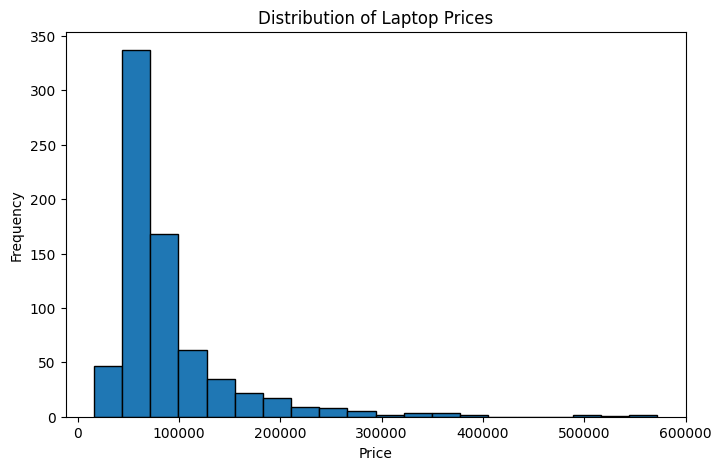

In [46]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=20, edgecolor="black")
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

##### 2. Brand Frequency (Using Bar Chart)
- Identifies the brands with the most laptop models.

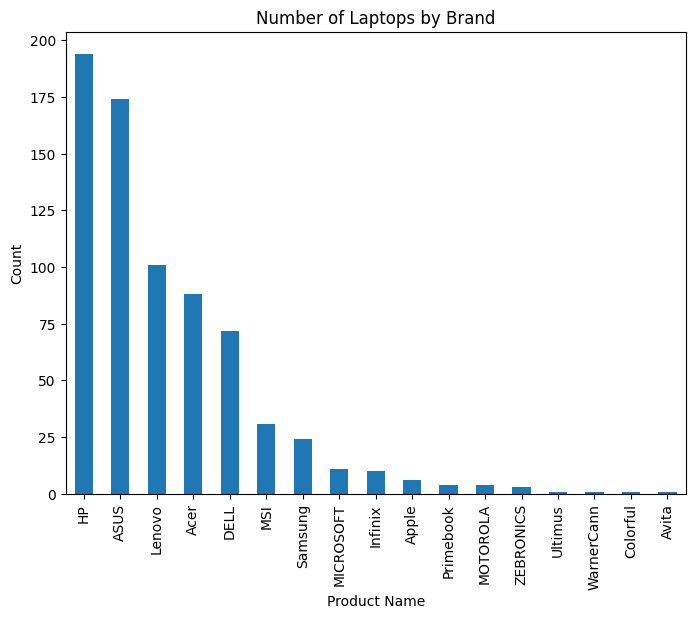

In [47]:
plt.figure(figsize=(8,6))
df["Brand"].value_counts().plot(kind="bar")
plt.title("Number of Laptops by Brand")
plt.xlabel("Product Name")
plt.ylabel("Count")
plt.show()

#### 3. Price Distribution (Using Box Plot)
- Detects outliers in laptop prices.

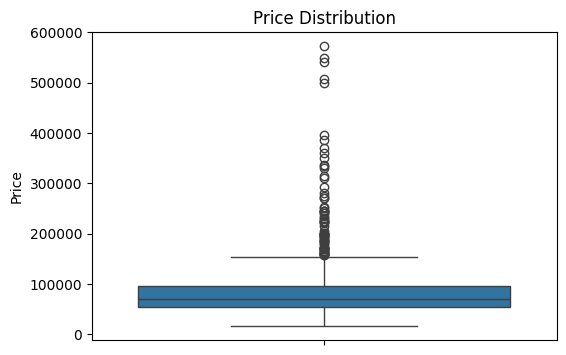

In [48]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Price"])
plt.title("Price Distribution")
plt.show()

### B. Bivariate Analysis
**Bivariate analysis studies the relationship between two variables.**

#### 4. Brand vs Average Price
- Compares the average price of different laptop brands.

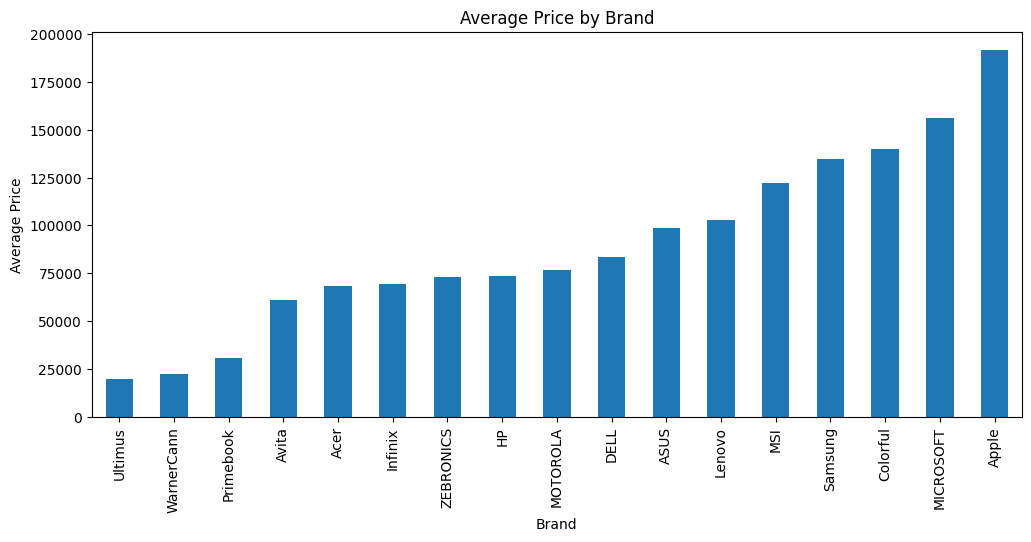

In [49]:
plt.figure(figsize=(12,5))
df.groupby("Brand")["Price"].mean().sort_values().plot(kind="bar")
plt.title("Average Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.show()

#### 5. Price vs Rating (Scatter Plot)
- Checks whether higher-priced laptops tend to have better ratings.

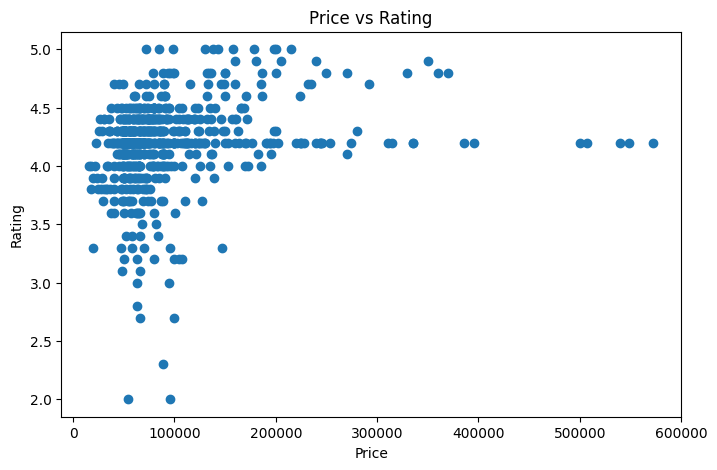

In [50]:
plt.figure(figsize=(8,5))
plt.scatter(df["Price"], df["Rating"])
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

#### 6. Discount by Brand
- Shows which brands generally offer larger discounts.

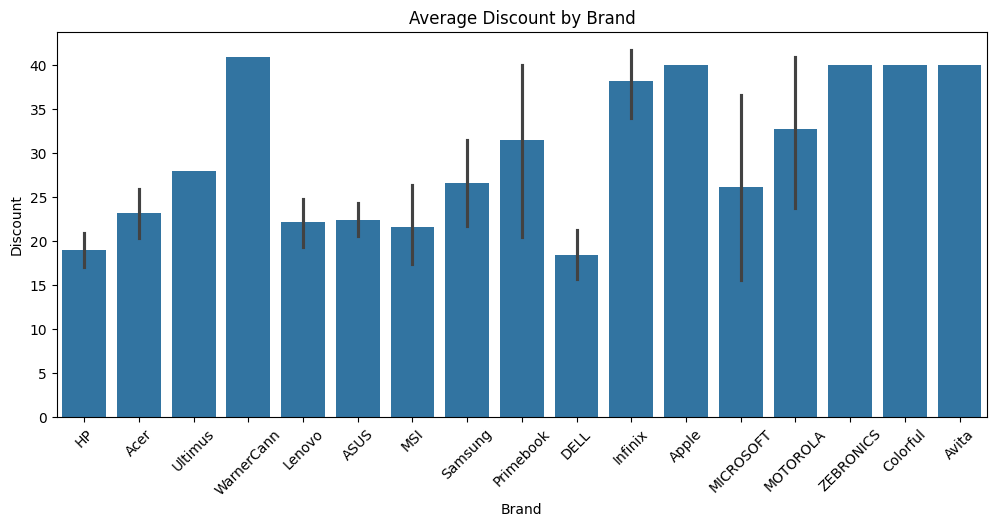

In [51]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="Brand", y="Discount")
plt.xticks(rotation=45)
plt.title("Average Discount by Brand")
plt.show()

### C. Multivariate Analysis
- Multivariate analysis examines more than two variables simultaneously.

#### 7. Correlation Heatmap
- Displays correlations among numeric features such as Price, Discount, Rating, RAM_GB, and Display_Inches.

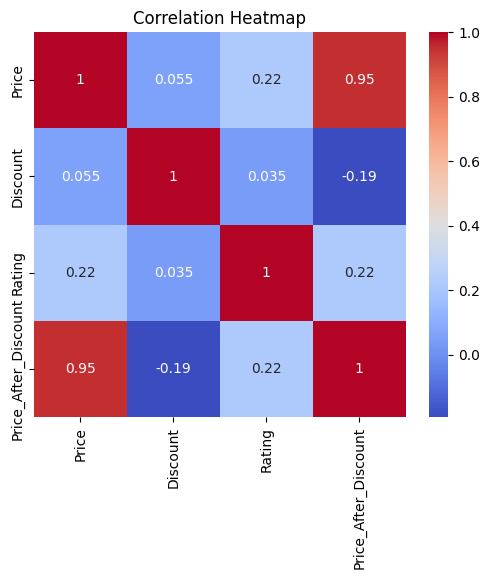

In [52]:
plt.figure(figsize=(6,5))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

#### 8. Price by Brand and Price Category
- Compares laptop prices across brands while separating them into categories such as Budget and Premium.

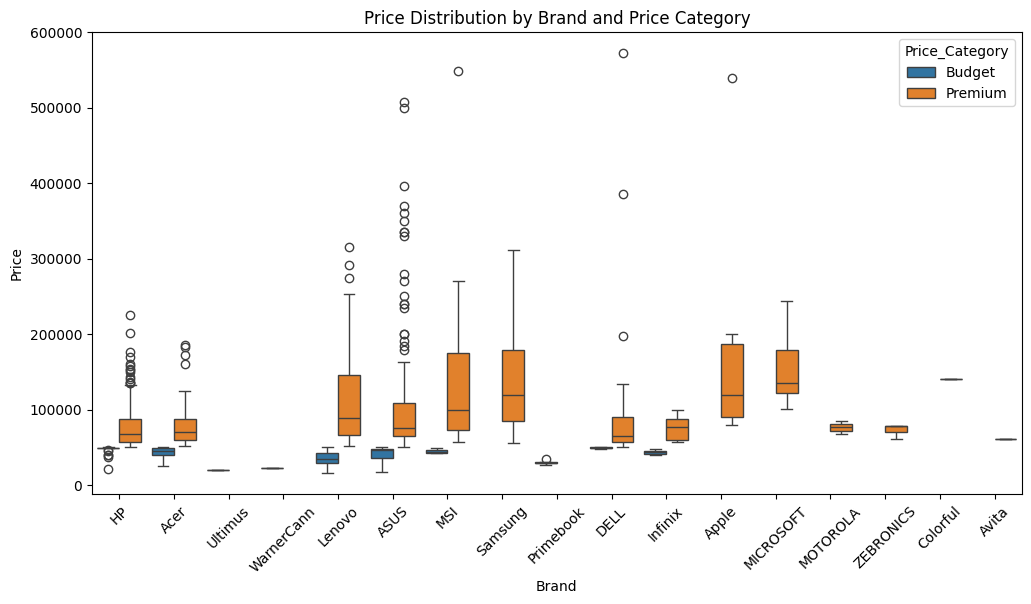

In [53]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,
            x="Brand",
            y="Price",
            hue="Price_Category")

plt.xticks(rotation=45)
plt.title("Price Distribution by Brand and Price Category")
plt.show()

#### 9. Pie Chart of Laptop Brands

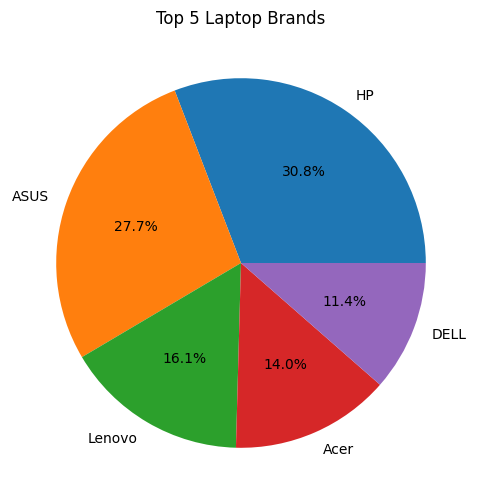

In [54]:
df["Brand"].value_counts().head(5).plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.title("Top 5 Laptop Brands")
plt.ylabel("")
plt.show()

#### 10. RAM Distribution

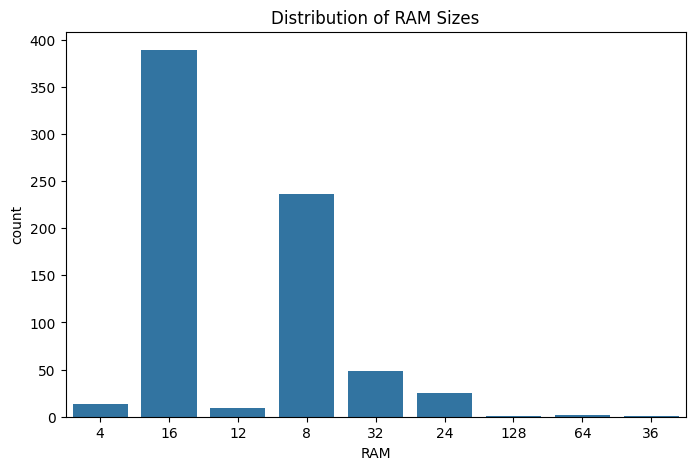

In [55]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="RAM")
plt.title("Distribution of RAM Sizes")
plt.show()